In [521]:
import pandas as pd
import numpy as np
from tqdm.auto import tqdm, trange
import re
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

In [522]:
data = pd.read_csv('dump3.csv')

In [523]:
data.shape

(83707, 5)

In [524]:
data.head(5)

,name,Артикул,category,Цена без карты,Цена с картой
0,Проходка BORGE Кровельная D6-50мм прямая №1,17162301,"Главная,Каталог,Строительные материалы,Кровля,...",329.33 ₽,312.86 ₽
1,Аэратор ТЕХНОНИКОЛЬ КТВ,17575401,"Главная,Каталог,Строительные материалы,Кровля,...",1 529.00 ₽,1 452.55 ₽
2,Аэратор ТЕХНОНИКОЛЬ Pilot скатный,17575301,"Главная,Каталог,Строительные материалы,Кровля,...",3 008.00 ₽,2 857.60 ₽
3,Проходной элемент ТЕХНОНИКОЛЬ Shinglas,17575701,"Главная,Каталог,Строительные материалы,Кровля,...",1 172.00 ₽,1 113.40 ₽
4,Вентиль ТЕХНОНИКОЛЬ Skat кровельный,17575501,"Главная,Каталог,Строительные материалы,Кровля,...",2 396.00 ₽,2 276.20 ₽


In [525]:
print(data['category'].unique(), len(data['category'].unique()))

['Главная,Каталог,Строительные материалы,Кровля,Вентиляция для кровли'
 'Главная,Каталог,Строительные материалы,Кровля,Волнистый лист (ондулин)'
 'Главная,Каталог,Строительные материалы,Кровля,Кровельные мастики'
 'Главная,Каталог,Строительные материалы,Кровля,Кровельные ограждения, снегодержатели'
 'Главная,Каталог,Строительные материалы,Кровля,Металлочерепица'
 'Главная,Каталог,Строительные материалы,Кровля,Мягкая черепица'
 'Главная,Каталог,Строительные материалы,Кровля,Профнастил'
 'Главная,Каталог,Строительные материалы,Кровля,Рулонная кровля'
 'Главная,Каталог,Строительные материалы,Строительные сухие смеси и клеи,Затирки'
 'Главная,Каталог,Строительные материалы,Строительные сухие смеси и клеи,Клеи'
 'Главная,Каталог,Строительные материалы,Строительные сухие смеси и клеи,Ровнители для пола'
 'Главная,Каталог,Строительные материалы,Строительные сухие смеси и клеи,Специальные смеси'
 'Главная,Каталог,Строительные материалы,Строительные сухие смеси и клеи,Шпаклевки'
 'Главная,Катал

In [526]:
print(data['name'].unique(), len(data['name'].unique()))

['Проходка BORGE Кровельная D6-50мм прямая №1' 'Аэратор ТЕХНОНИКОЛЬ КТВ'
 'Аэратор ТЕХНОНИКОЛЬ Pilot скатный' ...
 'Решётка заборная FULEREN 15х15 0,5х5мх'
 'Решётка заборная FULEREN 15х15 0,5х10м'
 'Сетка сварная FULEREN Оцинкованная 50х100 1,8х15м'] 82921


# Выборка данных

In [527]:
topics = set(data.category)
pack_in_cat = 130

In [528]:
df_res = pd.DataFrame()

for topic in tqdm(topics):
    df_topic = data[data['category'] == topic][:pack_in_cat]
    df_res = df_res.append(df_topic)

  0%|          | 0/872 [00:00<?, ?it/s]

In [529]:
df_res.shape

(45210, 5)


# Предобработка

In [530]:
import string
def remove_punctuation(text):
    return "".join([ch if ch not in string.punctuation else ' ' for ch in text])

def remove_numbers(text):
    return ''.join([i if not i.isdigit() else ' ' for i in text])

import re
def remove_multiple_spaces(text):
	return re.sub(r'\s+', ' ', text, flags=re.I)

import nltk
nltk.download('stopwords')
from nltk.stem import *
from nltk.corpus import stopwords
from pymystem3 import Mystem
from string import punctuation
mystem = Mystem() 

russian_stopwords = stopwords.words("russian")
russian_stopwords.extend(['…', '«', '»', '...'])
def lemmatize_text(text):
    tokens = mystem.lemmatize(text.lower())
    tokens = [token for token in tokens if token not in russian_stopwords and token != " "]
    text = " ".join(tokens)
    return text

[nltk_data] Downloading package stopwords to
[nltk_data]     /home/mugichu/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


<ipython-input-531-6083d33376df>:26: MatplotlibDeprecationWarning: Adding an axes using the same arguments as a previous axes currently reuses the earlier instance.  In a future version, a new instance will always be created and returned.  Meanwhile, this warning can be suppressed, and the future behavior ensured, by passing a unique label to each axes instance.
  plt.subplot(1, 2, 1)


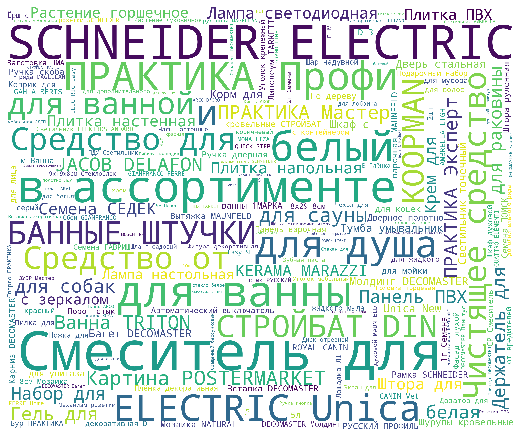

In [531]:
def str_corpus(corpus):
    str_corpus = ''
    for i in corpus:
        str_corpus += ' ' + i
    str_corpus = str_corpus.strip()
    return str_corpus
# Получение списка всех слов в корпусе
def get_corpus(data):
    corpus = []
    for phrase in data:
        for word in phrase.split():
            corpus.append(word)
    return corpus
# Получение облака слов
def get_wordCloud(corpus):
    wordCloud = WordCloud(background_color='white',width=3000,height=2500,max_words=200,random_state=42).generate(str_corpus(corpus))
    return wordCloud

corpus = get_corpus(df_res['name'].values)
procWordCloud = get_wordCloud(corpus)

fig = plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.imshow(procWordCloud)
plt.axis('off')
plt.subplot(1, 2, 1)

In [532]:
prep_text = [remove_multiple_spaces(remove_numbers(remove_punctuation(text.lower()))) for text in tqdm(df_res['name'])]


  0%|          | 0/45210 [00:00<?, ?it/s]

In [533]:
len(prep_text)
prep_text[1]

'паркетная доска tarkett salsa дуб селект'

In [534]:
df_res['text_prep'] = prep_text
df_res.head(1)

,name,Артикул,category,Цена без карты,Цена с картой,text_prep
15644,Паркетная доска СИНТЕРОС Europarquet Дуб янтарный,3513001,"Главная,Каталог,Напольные покрытия,Паркет",4 320.00 ₽,4 104.00 ₽,паркетная доска синтерос europarquet дуб янтарный


In [535]:
from nltk.stem.snowball import SnowballStemmer 
stemmer = SnowballStemmer("russian")

In [536]:
russian_stopwords = stopwords.words("russian")
russian_stopwords.extend(['…', '«', '»', '...', 'т.д.', 'т', 'д','Главная','Каталог'])

In [537]:
import nltk
nltk.download('punkt')
from nltk import word_tokenize
text = df_res['text_prep'][0]
word_tokenize(text)

[nltk_data] Downloading package punkt to /home/mugichu/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


['проходка', 'borge', 'кровельная', 'd', 'мм', 'прямая', '№']

In [538]:
from nltk import word_tokenize

stemmed_texts_list = []
for text in tqdm(df_res['text_prep']):
    tokens = word_tokenize(text)    
    stemmed_tokens = [stemmer.stem(token) for token in tokens if token not in russian_stopwords]
    text = " ".join(stemmed_tokens)
    stemmed_texts_list.append(text)

df_res['text_stem'] = stemmed_texts_list

  0%|          | 0/45210 [00:00<?, ?it/s]

In [539]:
def remove_stop_words(text):
    tokens = word_tokenize(text) 
    tokens = [token for token in tokens if token not in russian_stopwords and token != ' ']
    return " ".join(tokens)

In [540]:
from nltk import word_tokenize

sw_texts_list = []
for text in tqdm(df_res['text_prep']):
    tokens = word_tokenize(text)    
    tokens = [token for token in tokens if token not in russian_stopwords and token != ' ']
    text = " ".join(tokens)
    sw_texts_list.append(text)

df_res['text_sw'] = sw_texts_list

  0%|          | 0/45210 [00:00<?, ?it/s]

In [541]:
df_res['text_sw'][0]

'проходка borge кровельная d мм прямая №'

In [542]:
df_res.to_csv('sp_stemmed.csv')

In [543]:
df_res['text_stem'][0]

'проходк borge кровельн d мм прям №'

# Лемматизация

In [544]:
lemm_texts_list = []
for text in tqdm(df_res['text_sw']):
    #print(text)
    try:
        text_lem = mystem.lemmatize(text)
        tokens = [token for token in text_lem if token != ' ' and token not in russian_stopwords]
        text = " ".join(tokens)
        lemm_texts_list.append(text)
    except Exception as e:
        print(e)
    
df_res['text_lemm'] = lemm_texts_list

  0%|          | 0/45210 [00:00<?, ?it/s]

In [545]:
def lemmatize_text(text):
    text_lem = mystem.lemmatize(text)
    tokens = [token for token in text_lem if token != ' ']
    return " ".join(tokens)

In [546]:
df_res.to_csv('lemm.csv')

In [547]:
df_res = pd.read_csv('lemm.csv', encoding = 'utf-8')

In [548]:
df_res.head()

,Unnamed: 0,name,Артикул,category,Цена без карты,Цена с картой,text_prep,text_stem,text_sw,text_lemm
0,15644,Паркетная доска СИНТЕРОС Europarquet Дуб янтарный,3513001,"Главная,Каталог,Напольные покрытия,Паркет",4 320.00 ₽,4 104.00 ₽,паркетная доска синтерос europarquet дуб янтарный,паркетн доск синтерос europarquet дуб янтарн,паркетная доска синтерос europarquet дуб янтарный,паркетный доска синтерос europarquet дуб янтар...
1,15645,Паркетная доска TARKETT Salsa Дуб селект,146173,"Главная,Каталог,Напольные покрытия,Паркет",3 514.84 ₽,3 339.10 ₽,паркетная доска tarkett salsa дуб селект,паркетн доск tarkett salsa дуб селект,паркетная доска tarkett salsa дуб селект,паркетный доска tarkett salsa дуб селект \n
2,15646,Паркетная доска TARKETT Salsa Дуб натур,146171,"Главная,Каталог,Напольные покрытия,Паркет",2 693.59 ₽,2 558.91 ₽,паркетная доска tarkett salsa дуб натур,паркетн доск tarkett salsa дуб натур,паркетная доска tarkett salsa дуб натур,паркетный доска tarkett salsa дуб натура \n
3,15647,Паркетная доска СИНТЕРОС Europarquet Ясень нордик,3513101,"Главная,Каталог,Напольные покрытия,Паркет",6 465.00 ₽,6 141.75 ₽,паркетная доска синтерос europarquet ясень нордик,паркетн доск синтерос europarquet ясен нордик,паркетная доска синтерос europarquet ясень нордик,паркетный доска синтерос europarquet ясень нор...
4,15648,Паркетная доска СИНТЕРОС Europarquet Бук классик,3512901,"Главная,Каталог,Напольные покрытия,Паркет",5 226.00 ₽,4 964.70 ₽,паркетная доска синтерос europarquet бук классик,паркетн доск синтерос europarquet бук классик,паркетная доска синтерос europarquet бук классик,паркетный доска синтерос europarquet бук класс...


In [549]:
df_res['text_lemm'][0]

'паркетный доска синтерос europarquet дуб янтарный \n'

In [550]:
X = df_res['text_sw']
y = df_res['category']

In [551]:
type(df_res['text_lemm'][0])

str

In [593]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.85, random_state = 127)

In [594]:
my_cat = df_res['category'].unique()
my_cat

array(['Главная,Каталог,Напольные покрытия,Паркет',
       'Главная,Каталог,Отопление, водоснабжение, канализация,Системы водоснабжения и канализации,Запорная и регулировочная арматура',
       'Главная,Каталог,Сад и огород,Агрохимия,Органические и органоминеральные удобрения для садовых растений',
       'Главная,Каталог,Краски, герметики, пропитки,Морилки',
       'Главная,Каталог,Кухни, мойки, смесители, бытовая техника,Бытовая техника,Кипятильники',
       'Главная,Каталог,Товары для дома, подарки, бытовая химия,Личная гигиена,Презервативы',
       'Главная,Каталог,Автотовары,Герметики и холодная сварка',
       'Главная,Каталог,Инструменты и крепёж,Расходные материалы для инструмента,Расходные материалы для степлеров',
       'Главная,Каталог,Сантехника, мебель для ванной комнаты,Санфаянс,Унитазы',
       'Главная,Каталог,Сад и огород,Ёмкости для растений,Поддоны',
       'Главная,Каталог,Сад и огород,Садовый ручной инструмент,Лопаты',
       'Главная,Каталог,Инженерная электрика,

In [595]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfTransformer
from sklearn.feature_extraction.text import CountVectorizer

In [596]:
nb = Pipeline([('vect', CountVectorizer()),
               ('tfidf', TfidfTransformer()),
               ('clf', MultinomialNB()),
              ])

In [597]:
%%time
nb.fit(X_train, y_train)

CPU times: user 454 ms, sys: 92.3 ms, total: 547 ms
Wall time: 551 ms


Pipeline(steps=[('vect', CountVectorizer()), ('tfidf', TfidfTransformer()),
                ('clf', MultinomialNB())])

In [598]:
%%time
from sklearn.metrics import classification_report
y_pred = nb.predict(X_test)

CPU times: user 544 ms, sys: 204 ms, total: 749 ms
Wall time: 748 ms


In [599]:
y_pred[0]

'Главная,Каталог,Инженерная электрика, лампы,Розетки и выключатели,Рамки'

In [600]:
print(X_test[0], y_test[0], y_pred[0])

паркетная доска синтерос europarquet дуб янтарный Главная,Каталог,Напольные покрытия,Паркет Главная,Каталог,Инженерная электрика, лампы,Розетки и выключатели,Рамки


In [601]:
from sklearn.metrics import accuracy_score

print('accuracy %s' % accuracy_score(y_pred, y_test))
print(classification_report(y_test, y_pred, target_names=my_cat))

accuracy 0.580395014181998


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1221: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


                                                                                                                                           precision    recall  f1-score   support

                                                                                                Главная,Каталог,Напольные покрытия,Паркет       0.38      0.86      0.52        99
             Главная,Каталог,Отопление, водоснабжение, канализация,Системы водоснабжения и канализации,Запорная и регулировочная арматура       0.00      0.00      0.00        34
                                   Главная,Каталог,Сад и огород,Агрохимия,Органические и органоминеральные удобрения для садовых растений       0.71      0.88      0.79        59
                                                                                      Главная,Каталог,Краски, герметики, пропитки,Морилки       0.00      0.00      0.00         1
                                                    Главная,Каталог,Кухни, мойки, смесители, бытовая тех

In [602]:
from sklearn.linear_model import SGDClassifier

sgd = Pipeline([('vect', CountVectorizer()),
                ('tfidf', TfidfTransformer()),
                ('clf', SGDClassifier(loss='hinge', penalty='l2',alpha=1e-3, random_state=42, max_iter=5, tol=None)),
               ])

In [603]:
%%time
sgd.fit(X_train, y_train)

CPU times: user 2.15 s, sys: 48 ms, total: 2.2 s
Wall time: 2.25 s


Pipeline(steps=[('vect', CountVectorizer()), ('tfidf', TfidfTransformer()),
                ('clf',
                 SGDClassifier(alpha=0.001, max_iter=5, random_state=42,
                               tol=None))])

In [604]:
%%time
y_pred = sgd.predict(X_test)

CPU times: user 644 ms, sys: 140 ms, total: 784 ms
Wall time: 783 ms


In [605]:
from sklearn.metrics import accuracy_score
print('accuracy %s' % accuracy_score(y_pred, y_test))
print(classification_report(y_test, y_pred, target_names=my_cat))

accuracy 0.7813630331260246


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1221: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


                                                                                                                                           precision    recall  f1-score   support

                                                                                                Главная,Каталог,Напольные покрытия,Паркет       0.65      0.68      0.66        99
             Главная,Каталог,Отопление, водоснабжение, канализация,Системы водоснабжения и канализации,Запорная и регулировочная арматура       0.92      1.00      0.96        34
                                   Главная,Каталог,Сад и огород,Агрохимия,Органические и органоминеральные удобрения для садовых растений       0.70      0.98      0.82        59
                                                                                      Главная,Каталог,Краски, герметики, пропитки,Морилки       1.00      1.00      1.00         1
                                                    Главная,Каталог,Кухни, мойки, смесители, бытовая тех

In [606]:
from sklearn.linear_model import SGDClassifier

sgd = Pipeline([('vect', CountVectorizer()),
                ('tfidf', TfidfTransformer()),
                ('clf', SGDClassifier(loss='hinge', penalty='l2',alpha=1e-3, random_state=42, max_iter=3, tol=None)),
               ])

In [607]:
%%time
sgd.fit(X_train, y_train)

CPU times: user 1.34 s, sys: 23.3 ms, total: 1.36 s
Wall time: 1.38 s


Pipeline(steps=[('vect', CountVectorizer()), ('tfidf', TfidfTransformer()),
                ('clf',
                 SGDClassifier(alpha=0.001, max_iter=3, random_state=42,
                               tol=None))])

In [608]:
%%time
y_pred = sgd.predict(X_test)

CPU times: user 480 ms, sys: 120 ms, total: 600 ms
Wall time: 599 ms


In [609]:
print('accuracy %s' % accuracy_score(y_pred, y_test))
print(classification_report(y_test, y_pred,target_names=my_cat))

accuracy 0.775377969762419


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1221: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


                                                                                                                                           precision    recall  f1-score   support

                                                                                                Главная,Каталог,Напольные покрытия,Паркет       0.66      0.68      0.67        99
             Главная,Каталог,Отопление, водоснабжение, канализация,Системы водоснабжения и канализации,Запорная и регулировочная арматура       0.92      1.00      0.96        34
                                   Главная,Каталог,Сад и огород,Агрохимия,Органические и органоминеральные удобрения для садовых растений       0.69      0.98      0.81        59
                                                                                      Главная,Каталог,Краски, герметики, пропитки,Морилки       1.00      1.00      1.00         1
                                                    Главная,Каталог,Кухни, мойки, смесители, бытовая тех

In [610]:
from sklearn.linear_model import LogisticRegression

logreg = Pipeline([('vect', CountVectorizer()),
                ('tfidf', TfidfTransformer()),
                ('clf', LogisticRegression(n_jobs=1, C=1e5)),
               ])

In [611]:
%%time
logreg.fit(X_train, y_train)

CPU times: user 2min 39s, sys: 15.3 s, total: 2min 54s
Wall time: 2min 54s


/usr/local/lib/python3.8/dist-packages/sklearn/linear_model/_logistic.py:762: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Pipeline(steps=[('vect', CountVectorizer()), ('tfidf', TfidfTransformer()),
                ('clf', LogisticRegression(C=100000.0, n_jobs=1))])

In [612]:
%%time
y_pred = logreg.predict(X_test)

CPU times: user 803 ms, sys: 244 ms, total: 1.05 s
Wall time: 1.07 s


In [613]:
print('accuracy %s' % accuracy_score(y_pred, y_test))
print(classification_report(y_test, y_pred,target_names=my_cat))

accuracy 0.8270056467771735


/usr/local/lib/python3.8/dist-packages/sklearn/metrics/_classification.py:1221: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


                                                                                                                                           precision    recall  f1-score   support

                                                                                                Главная,Каталог,Напольные покрытия,Паркет       0.67      0.89      0.77        99
             Главная,Каталог,Отопление, водоснабжение, канализация,Системы водоснабжения и канализации,Запорная и регулировочная арматура       0.92      1.00      0.96        34
                                   Главная,Каталог,Сад и огород,Агрохимия,Органические и органоминеральные удобрения для садовых растений       0.96      0.90      0.93        59
                                                                                      Главная,Каталог,Краски, герметики, пропитки,Морилки       1.00      1.00      1.00         1
                                                    Главная,Каталог,Кухни, мойки, смесители, бытовая тех

In [636]:
test_text = 'Проходка BORGE Кровельная D6-50мм прямая №1'

In [637]:
test_text = remove_multiple_spaces(remove_numbers(remove_punctuation(test_text.lower())))
test_text = remove_stop_words(test_text)

In [638]:
%%time
test_text = lemmatize_text(test_text)

CPU times: user 2.36 ms, sys: 131 µs, total: 2.49 ms
Wall time: 20.3 ms


In [639]:
test_text

'проходка borge кровельный d мм прямой № \n'

In [640]:
test_pred = nb.predict([test_text])
test_pred

array(['Главная,Каталог,Хранение и порядок,Хранение,Гардеробные системы'],
      dtype='<U137')

In [641]:
test_pred = sgd.predict([test_text])
test_pred

array(['Главная,Каталог,Строительные материалы,Кровля,Кровельные ограждения, снегодержатели'],
      dtype='<U137')

In [642]:
test_pred = logreg.predict([test_text]) #logreg.predict определяет хуже чем sgd.predict про nb.predict я вообщепромолчу точность 49
test_pred

array(['Главная,Каталог,Строительные материалы,Кровля,Кровельные ограждения, снегодержатели'],
      dtype=object)

In [621]:
# но если и выбирать то только из последних двух